In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [12]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

df.head()

Saving Loan prediction.csv to Loan prediction (1).csv


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [13]:
#First 10 Records
print(df.head(10))

# Features and Target
print("Features:")
print(df.columns[:-1])

print("\nTarget Variable:")
print(df.columns[-1])

# Number of Records and Attributes
print(df.shape)
# Missing Values
print(df.isnull().sum())
# Statistical Properties
print(df.describe())

    Loan_ID Gender Married Dependents     Education Self_Employed  \
0  LP001002   Male      No          0      Graduate            No   
1  LP001003   Male     Yes          1      Graduate            No   
2  LP001005   Male     Yes          0      Graduate           Yes   
3  LP001006   Male     Yes          0  Not Graduate            No   
4  LP001008   Male      No          0      Graduate            No   
5  LP001011   Male     Yes          2      Graduate           Yes   
6  LP001013   Male     Yes          0  Not Graduate            No   
7  LP001014   Male     Yes         3+      Graduate            No   
8  LP001018   Male     Yes          2      Graduate            No   
9  LP001020   Male     Yes          1      Graduate            No   

   ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
0             5849                0.0         NaN             360.0   
1             4583             1508.0       128.0             360.0   
2             3000         

In [14]:
#Handle Missing Values
categorical = ['Gender','Married','Dependents','Self_Employed','Loan_Amount_Term','Credit_History']

for col in categorical:
    df[col].fillna(df[col].mode()[0], inplace=True)

numerical = ['LoanAmount']

for col in numerical:
    df[col].fillna(df[col].mean(), inplace=True)

#Convert Categorical Variables
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = encoder.fit_transform(df[col])

df.head()
#Normalize Numerical Features
scaler = StandardScaler()

num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount']

df[num_cols] = scaler.fit_transform(df[num_cols])

df.head()

#Feature Matrix and Target
X = df.drop("Loan_Status",axis=1)

y = df["Loan_Status"]

/tmp/ipykernel_3260/4094050420.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_3260/4094050420.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

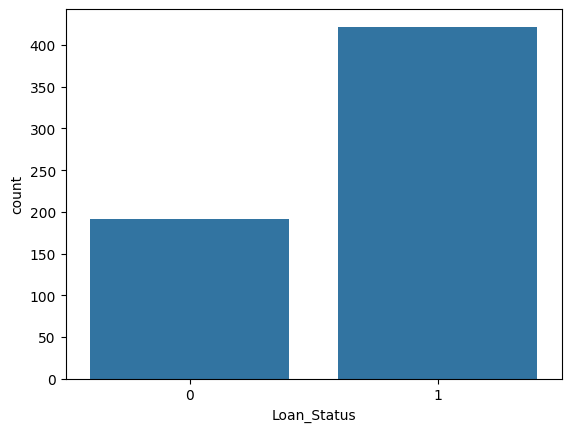

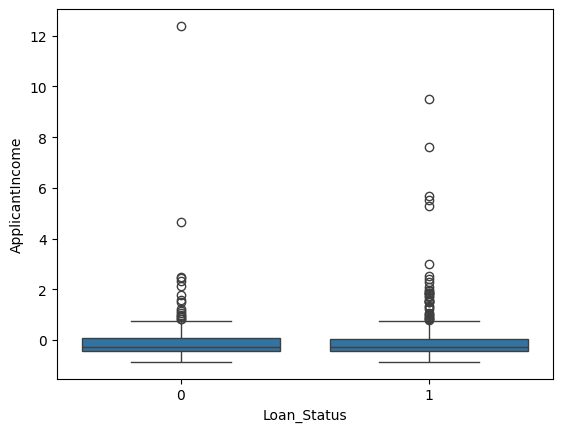

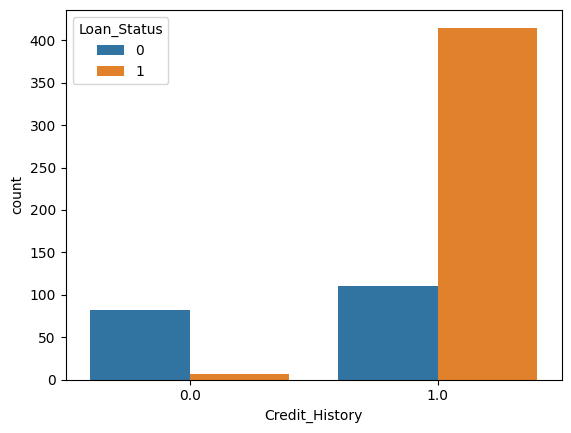

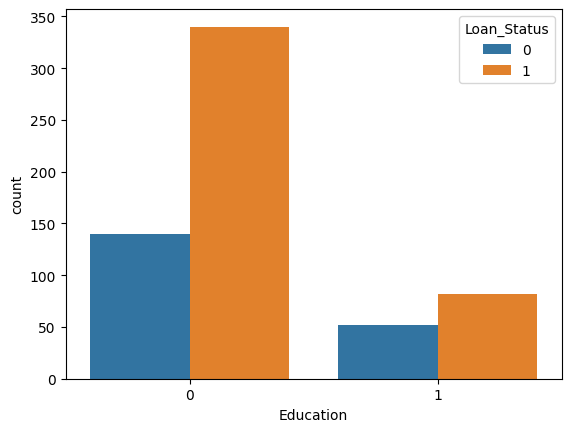

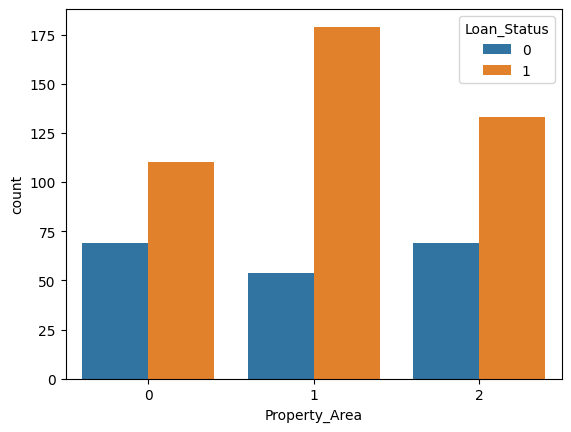

In [15]:
#Loan Approval Distribution
sns.countplot(x="Loan_Status",data=df)

plt.show()

# Applicant Income vs Loan Approval
sns.boxplot(x="Loan_Status",
            y="ApplicantIncome",
            data=df)

plt.show()

#Credit History vs Loan Approval
sns.countplot(x="Credit_History",
              hue="Loan_Status",
              data=df)

plt.show()

# Education vs Loan Approval
sns.countplot(x="Education",
              hue="Loan_Status",
              data=df)

plt.show()

#Property Area vs Loan Approval
sns.countplot(x="Property_Area",
              hue="Loan_Status",
              data=df)

plt.show()

In [16]:
#Train Test Split
X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

#Logistic Regression
lr=LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

#Decision Tree
dt=DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

pred_dt=dt.predict(X_test)

#Random Forest
rf=RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

#Performance Metrics
results=pd.DataFrame({

'Model':['Logistic Regression','Decision Tree','Random Forest'],

'Accuracy':[

accuracy_score(y_test,pred_lr),

accuracy_score(y_test,pred_dt),

accuracy_score(y_test,pred_rf)

],

'Precision':[

precision_score(y_test,pred_lr),

precision_score(y_test,pred_dt),

precision_score(y_test,pred_rf)

],

'Recall':[

recall_score(y_test,pred_lr),

recall_score(y_test,pred_dt),

recall_score(y_test,pred_rf)

],

'F1 Score':[

f1_score(y_test,pred_lr),

f1_score(y_test,pred_dt),

f1_score(y_test,pred_rf)

]

})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108
1        Decision Tree  0.796748   0.840909  0.870588  0.855491
2        Random Forest  0.837398   0.835052  0.952941  0.890110


In [17]:
#Best Model
print(results.sort_values(by='Accuracy',ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.861789   0.840000  0.988235  0.908108
2        Random Forest  0.837398   0.835052  0.952941  0.890110
1        Decision Tree  0.796748   0.840909  0.870588  0.855491


In [18]:
#Logistic Regression
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

cv_lr=cross_val_score(lr,X,y,cv=skf)

print(cv_lr)

print("Mean:",cv_lr.mean())

print("Std:",cv_lr.std())

#Decision Tree
cv_dt=cross_val_score(dt,X,y,cv=skf)

print(cv_dt)

print("Mean:",cv_dt.mean())

print("Std:",cv_dt.std())

#Random Forest
cv_rf=cross_val_score(rf,X,y,cv=skf)

print(cv_rf)

print("Mean:",cv_rf.mean())

print("Std:",cv_rf.std())

#Compare Cross Validation
comparison=pd.DataFrame({

'Model':['Logistic Regression','Decision Tree','Random Forest'],

'Mean Accuracy':[

cv_lr.mean(),

cv_dt.mean(),

cv_rf.mean()

],

'Standard Deviation':[

cv_lr.std(),

cv_dt.std(),

cv_rf.std()

]

})

print(comparison)

[0.81300813 0.82113821 0.80487805 0.75609756 0.82786885]
Mean: 0.8045981607357058
Std: 0.025448821062939588
[0.68292683 0.74796748 0.72357724 0.67479675 0.7295082 ]
Mean: 0.7117552978808476
Std: 0.028154078771192127
[0.78861789 0.82926829 0.79674797 0.75609756 0.79508197]
Mean: 0.7931627349060376
Std: 0.023300778596783672
                 Model  Mean Accuracy  Standard Deviation
0  Logistic Regression       0.804598            0.025449
1        Decision Tree       0.711755            0.028154
2        Random Forest       0.793163            0.023301


In [21]:
#GridSearchCV
param_grid={

'n_estimators':[50,100,200],

'max_depth':[3,5,10],

'min_samples_split':[2,5,10]

}

grid=GridSearchCV(

RandomForestClassifier(random_state=42),

param_grid,

cv=5,

scoring='accuracy'

)

grid.fit(X_train,y_train)

#Best Parameters
print(grid.best_params_)

#Best Score
print(grid.best_score_)

#Evaluate Tuned Model
best_rf=grid.best_estimator_

pred_best=best_rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_best))

print("Precision:",precision_score(y_test,pred_best))

print("Recall:",recall_score(y_test,pred_best))

print("F1:",f1_score(y_test,pred_best))

#Compare Before and After
comparison=pd.DataFrame({

'Model':['Random Forest Before','Random Forest After'],

'Accuracy':[

accuracy_score(y_test,pred_rf),

accuracy_score(y_test,pred_best)

]

})

print(comparison)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
0.8004122861265719
Accuracy: 0.8455284552845529
Precision: 0.8235294117647058
Recall: 0.9882352941176471
F1: 0.8983957219251337
                  Model  Accuracy
0  Random Forest Before  0.837398
1   Random Forest After  0.845528


In [22]:
#Decision Tree Depth = 2
dt2=DecisionTreeClassifier(max_depth=2,random_state=42)

dt2.fit(X_train,y_train)

train2=dt2.score(X_train,y_train)

test2=dt2.score(X_test,y_test)

#Decision Tree Depth = 5
dt5=DecisionTreeClassifier(max_depth=5,random_state=42)

dt5.fit(X_train,y_train)

train5=dt5.score(X_train,y_train)

test5=dt5.score(X_test,y_test)

#Decision Tree Depth = 15
dt15=DecisionTreeClassifier(max_depth=15,random_state=42)

dt15.fit(X_train,y_train)

train15=dt15.score(X_train,y_train)

test15=dt15.score(X_test,y_test)

#Comparison Table
bias_variance=pd.DataFrame({

'Max Depth':[2,5,15],

'Training Accuracy':[

train2,

train5,

train15

],

'Testing Accuracy':[

test2,

test5,

test15

]

})

print(bias_variance)

#Underfitting / Overfitting
print("Depth 2 : Underfitting")

print("Depth 15 : Overfitting")

print("Depth 5 : Best Bias-Variance Tradeoff")

   Max Depth  Training Accuracy  Testing Accuracy
0          2           0.804481          0.853659
1          5           0.824847          0.837398
2         15           1.000000          0.796748
Depth 2 : Underfitting
Depth 15 : Overfitting
Depth 5 : Best Bias-Variance Tradeoff
